In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_025_02_12_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_018_01_30_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_011_02_30_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_026_02_48_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_004_02_6_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_002_02_36_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_025_01_36_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_017_02_36_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_018_02_60_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_015_02_54_image.png
/kaggle/input/emergency-sign-language/Image_Data/call/colored_call_006_02_66_image.png
/kaggle/input/emergency-sign-language/Image_

In [2]:
# Install required packages
!pip install -q ultralytics supervision yolov10 mediapipe opencv-python-headless

print("✅ YOLOv10 Installed Successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 80.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.5/953.5 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 26.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━

In [3]:
import os
import glob
import shutil
from pathlib import Path
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

print("✅ Setup Complete!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Setup Complete!


In [4]:
# Base dataset path
DATASET_PATH = Path('/kaggle/input/emergency-sign-language/Image_Data')

# Get class names
classes = sorted([d.name for d in DATASET_PATH.iterdir()])
print("Classes:", classes)


Classes: ['accident', 'call', 'doctor', 'help', 'hot', 'lose', 'pain', 'thief']


In [5]:
# Remove old dataset if exists
!rm -rf /kaggle/working/yolo_dataset

# Create folder structure
os.makedirs('/kaggle/working/yolo_dataset/images/train', exist_ok=True)
os.makedirs('/kaggle/working/yolo_dataset/images/val', exist_ok=True)
os.makedirs('/kaggle/working/yolo_dataset/labels/train', exist_ok=True)
os.makedirs('/kaggle/working/yolo_dataset/labels/val', exist_ok=True)

print("✅ YOLO Dataset Structure Created!")


✅ YOLO Dataset Structure Created!


In [6]:
print("🚀 BUILDING YOLO DATASET...")

train_count = val_count = 0

for cls_idx, cls_name in enumerate(classes):
    cls_path = f"/kaggle/input/emergency-sign-language/Image_Data/{cls_name}"
    
    imgs = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        imgs.extend(glob.glob(os.path.join(cls_path, ext)))
    
    if not imgs:
        print(f"⚠️ No images in {cls_name}")
        continue
        
    print(f"📸 {cls_name}: {len(imgs)} images")
    
    split = int(0.8 * len(imgs))
    train_imgs = imgs[:split]
    val_imgs = imgs[split:]
    
    # TRAIN
    for i, img_path in enumerate(train_imgs):
        filename = f"{cls_name}_train_{i}.jpg"
        dst_img = f"/kaggle/working/yolo_dataset/images/train/{filename}"
        dst_label = f"/kaggle/working/yolo_dataset/labels/train/{filename.replace('.jpg','.txt')}"
        
        shutil.copy2(img_path, dst_img)
        
        with open(dst_label, 'w') as f:
            f.write(f"{cls_idx} 0.5 0.5 0.4 0.4")
        
        train_count += 1
    
    # VAL
    for i, img_path in enumerate(val_imgs):
        filename = f"{cls_name}_val_{i}.jpg"
        dst_img = f"/kaggle/working/yolo_dataset/images/val/{filename}"
        dst_label = f"/kaggle/working/yolo_dataset/labels/val/{filename.replace('.jpg','.txt')}"
        
        shutil.copy2(img_path, dst_img)
        
        with open(dst_label, 'w') as f:
            f.write(f"{cls_idx} 0.5 0.5 0.4 0.4")
        
        val_count += 1

print(f"✅ Train: {train_count}")
print(f"✅ Val: {val_count}")


🚀 BUILDING YOLO DATASET...
📸 accident: 574 images
📸 call: 624 images
📸 doctor: 754 images
📸 help: 646 images
📸 hot: 667 images
📸 lose: 582 images
📸 pain: 664 images
📸 thief: 600 images
✅ Train: 4086
✅ Val: 1025


In [7]:
data = {
    'path': '/kaggle/working/yolo_dataset',
    'train': 'images/train',
    'val': 'images/val',
    'nc': len(classes),
    'names': {i: cls for i, cls in enumerate(classes)}
}

with open('/kaggle/working/emergency_signs.yaml', 'w') as f:
    yaml.dump(data, f)

print("✅ data.yaml Created!")
print(yaml.dump(data))


✅ data.yaml Created!
names:
  0: accident
  1: call
  2: doctor
  3: help
  4: hot
  5: lose
  6: pain
  7: thief
nc: 8
path: /kaggle/working/yolo_dataset
train: images/train
val: images/val



In [8]:
model = YOLO('yolov10n.pt')

print("🎯 YOLOv10 TRAINING STARTED...")

results = model.train(
    data='/kaggle/working/emergency_signs.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='emergsign_yolov10',
    patience=10,
    save=True,
    plots=True
)

print("🎉 TRAINING COMPLETE!")


🎯 YOLOv10 TRAINING STARTED...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/emergency_signs.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=emergsign_yolov10, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [9]:
model = YOLO('/kaggle/working/runs/detect/emergsign_yolov10/weights/best.pt')
print("✅ Best Model Loaded!")


✅ Best Model Loaded!


In [10]:
from IPython.display import Image, display

train_img_dir = "/kaggle/working/yolo_dataset/images/train"
class_samples = {}

for cls_name in classes:
    cls_imgs = [f for f in os.listdir(train_img_dir) if cls_name.lower() in f.lower()]
    if cls_imgs:
        class_samples[cls_name] = os.path.join(train_img_dir, cls_imgs[0])

sample_images = list(class_samples.values())

results = model.predict(
    source=sample_images,
    save=True,
    conf=0.25,
    iou=0.45,
    name='all_8_classes'
)

print("🎉 Detection Complete!")



0: 640x640 1 accident, 5.4ms
1: 640x640 1 call, 5.4ms
2: 640x640 1 doctor, 5.4ms
3: 640x640 1 help, 5.4ms
4: 640x640 1 hot, 5.4ms
5: 640x640 1 lose, 5.4ms
6: 640x640 1 pain, 5.4ms
7: 640x640 1 thief, 5.4ms
Speed: 3.4ms preprocess, 5.4ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/all_8_classes
🎉 Detection Complete!


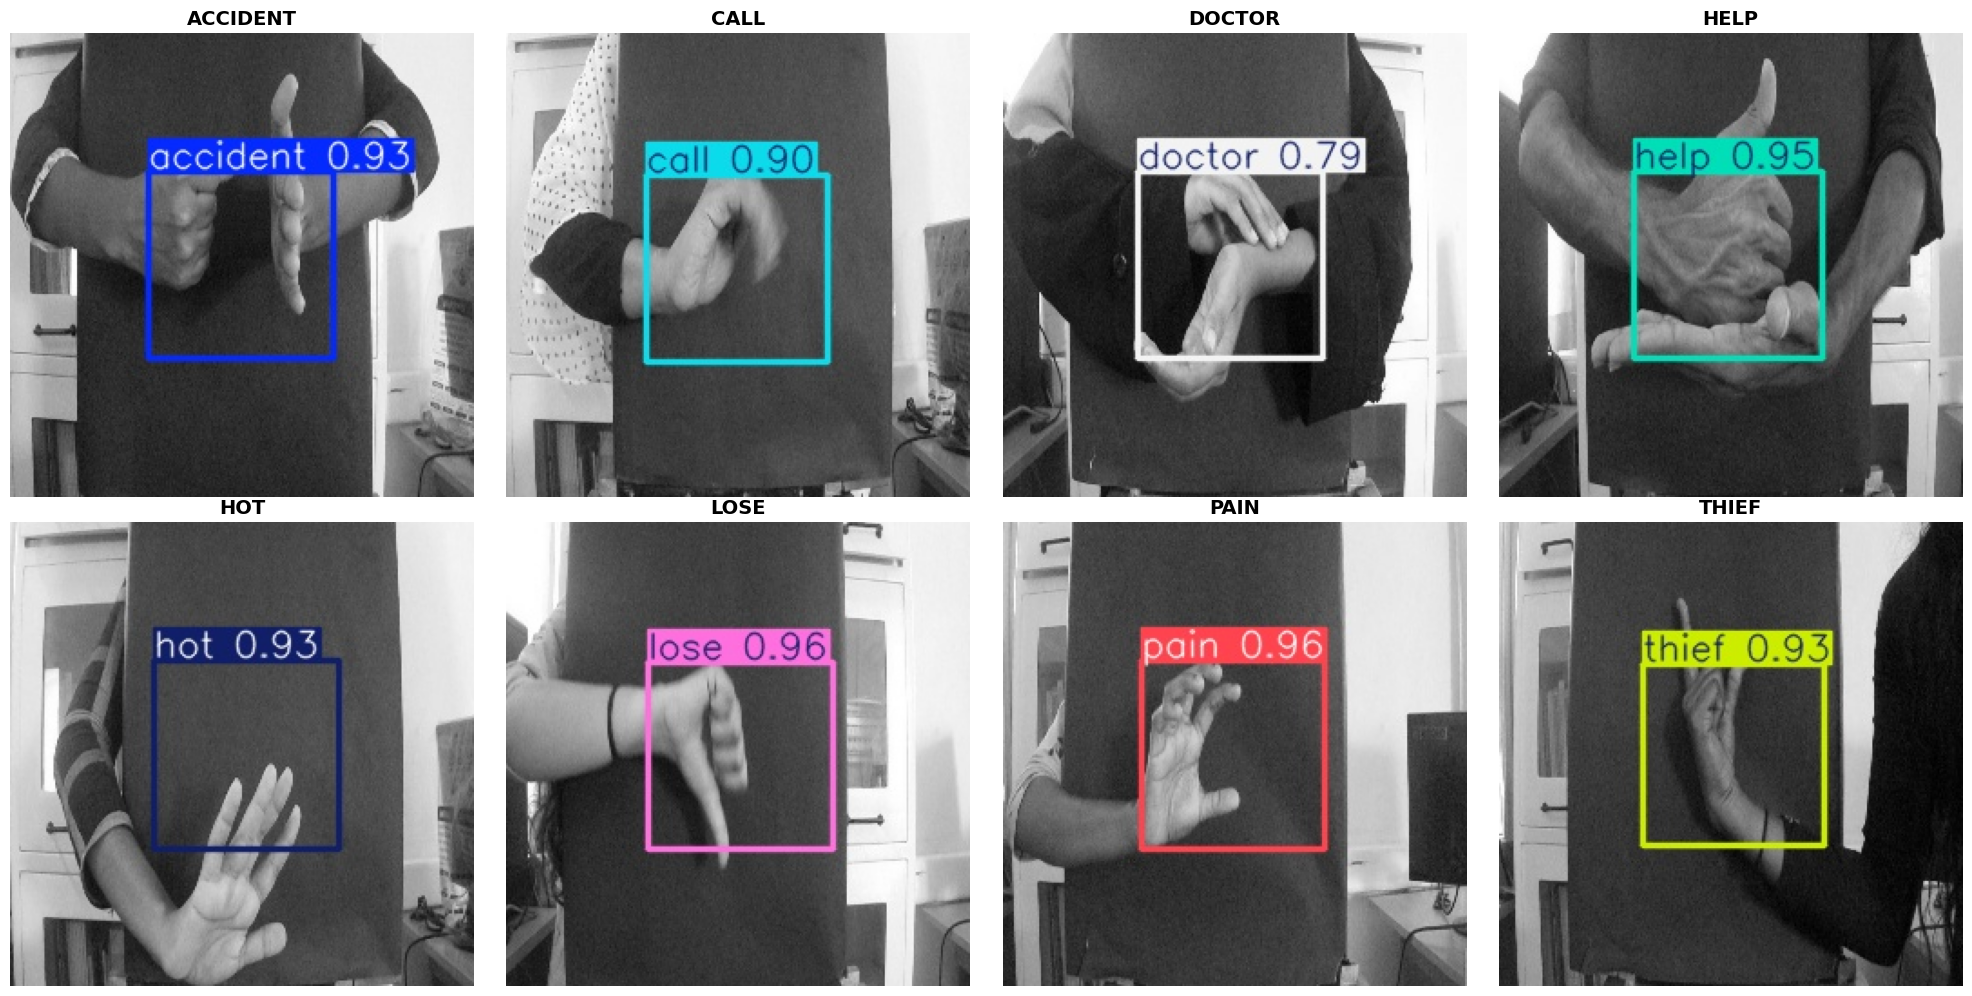

In [11]:
from PIL import Image as PILImage

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, (cls_name, img_path) in enumerate(class_samples.items()):
    result_path = f'/kaggle/working/runs/detect/all_8_classes/{os.path.basename(img_path)}'
    
    if os.path.exists(result_path):
        img = PILImage.open(result_path)
        axes[idx].imshow(img)
        axes[idx].set_title(cls_name.upper(), fontsize=14, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [12]:
model.export(format='onnx')
model.export(format='tflite')

print("✅ Model Exported Successfully!")


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/detect/emergsign_yolov10/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.5 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 171ms
Prepared 2 packages in 2.35s
Installed 2 packages in 16ms
 + onnxruntime-gpu==1.24.1
 + onnxslim==0.1.84

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/utils.py:1397: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/onnx/symbolic_opset9.py:5350: UserWarning: Exporting aten::index operator of advanced indexing in opset 22 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: slimming with onnxslim 0.1.84...
ONNX: export success ✅ 4.5s, saved as '/kaggle/working/runs/detect/emergsign_yolov10/weights/best.onnx' (8.9 MB)

Export complete (4.8s)
Results saved to /kaggle/working/runs/detect/emergsign_yolov10/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/emergsign_yolov10/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/emergsign_yolov10/weights/best.onnx imgsz=640 data=/kaggle/working/emergency_signs.yaml  
Visualize:       https://netron.app
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/detect/emergsign_yolov10/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.5 MB)


E0000 00:00:1770795327.833373      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770795327.879923      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770795328.256960      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770795328.256990      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770795328.257001      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770795328.257004      55 computation_placer.cc:177] computation placer already registered. Please check linka

requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3,<1.29.0'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 4.49s
Prepared 5 packages in 201ms
Installed 5 packages in 8ms
 + ai-edge-litert==2.1.2
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.8
 + sng4onnx==2.0.0

requirements: AutoUpdate success ✅ 4.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.20.1 opset 22...
ONNX: slimming with onnxslim 0.1.84...
ONNX: export success ✅ 1.2s, saved as '/kaggle/working/runs/detect/emergsign_yolov10/weights/best.onnx' (9.0 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /kaggle/working/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 51.6files/

I0000 00:00:1770795346.178093      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12945 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770795346.183153      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1770795349.066746      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Saved artifact at '/kaggle/working/runs/detect/emergsign_yolov10/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 300, 6), dtype=tf.float32, name=None)
Captures:
  138528807220048: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138528807218896: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  138528807219280: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  138528858048464: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138528807221200: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.float32, name=None)
  138528858047504: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  138528858048656: TensorSpec(shape=(1, 1, 32, 32), dtype=tf.float32, name=None)
  138528858048848: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  138528858049808: TensorSpec(shape=(4,), dtype=tf.int64,

I0000 00:00:1770795360.862486      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1770795360.862658      55 single_machine.cc:374] Starting new session
I0000 00:00:1770795360.875981      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12945 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770795360.877405      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
W0000 00:00:1770795361.768802      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770795361.768834      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1770795362.539815      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1770795362.539

TensorFlow SavedModel: export success ✅ 37.9s, saved as '/kaggle/working/runs/detect/emergsign_yolov10/weights/best_saved_model' (22.7 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/runs/detect/emergsign_yolov10/weights/best_saved_model/best_float32.tflite' (9.0 MB)

Export complete (38.2s)
Results saved to /kaggle/working/runs/detect/emergsign_yolov10/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/emergsign_yolov10/weights/best_saved_model/best_float32.tflite imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/emergsign_yolov10/weights/best_saved_model/best_float32.tflite imgsz=640 data=/kaggle/working/emergency_signs.yaml  
Visualize:       https://netron.app
✅ Model Exported Successfully!


In [13]:
from IPython.display import FileLink

model_path = '/kaggle/working/runs/detect/emergsign_yolov10/weights/best.pt'
display(FileLink(model_path))


/kaggle/working/runs/detect/emergsign_yolov10/weights/best.pt

In [14]:
from ultralytics import YOLO

# Load your best trained model
model = YOLO('/kaggle/working/runs/detect/emergsign_yolov10/weights/best.pt')

print("✅ Model Loaded Successfully!")


✅ Model Loaded Successfully!


In [15]:
metrics = model.val(data='/kaggle/working/emergency_signs.yaml')

print("📊 YOLO Official Metrics:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,266,728 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2600.0±730.8 MB/s, size: 112.2 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 1025 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1025/1025 358.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 65/65 7.6it/s 8.5s0.1s
                   all       1025       1025      0.997      0.999      0.995      0.995
              accident        115        115      0.997          1      0.995      0.995
                  call        125        125       0.99          1      0.995      0.995
                doctor        151        151          1          1      0.995      0.995
                  help        130        130      0.997          1      0.995      0.995
                   hot     

In [17]:
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

val_images_path = "/kaggle/working/yolo_dataset/images/val"

# model.names is a dictionary → {0:'accident',1:'call',...}
name_to_index = {v: k for k, v in model.names.items()}

y_true = []
y_pred = []

for img_name in os.listdir(val_images_path):
    
    if not img_name.endswith(".jpg"):
        continue
        
    img_path = os.path.join(val_images_path, img_name)
    
    # True class from filename
    true_class = img_name.split('_')[0]
    
    # Convert class name → index
    true_index = name_to_index[true_class]
    
    # Predict
    results = model.predict(img_path, conf=0.25, verbose=False)
    
    if len(results[0].boxes.cls) > 0:
        pred_index = int(results[0].boxes.cls[0])
    else:
        pred_index = -1  # No detection
    
    y_true.append(true_index)
    y_pred.append(pred_index)

# Remove images where nothing was detected
filtered = [(t, p) for t, p in zip(y_true, y_pred) if p != -1]

y_true = [t for t, p in filtered]
y_pred = [p for t, p in filtered]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("📊 Custom Classification Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


📊 Custom Classification Metrics:
Accuracy:  0.9980
Precision: 0.9981
Recall:    0.9980
F1 Score:  0.9980


<Figure size 800x800 with 0 Axes>

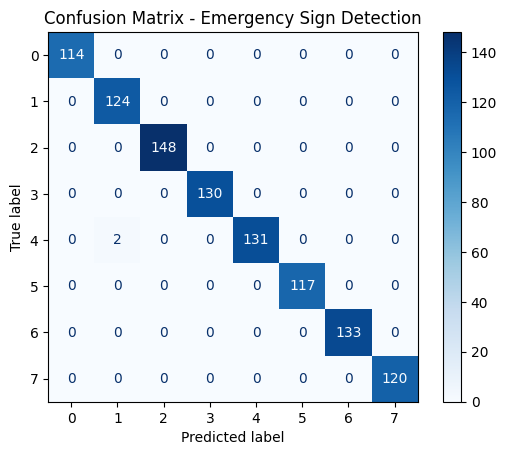

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.names)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Emergency Sign Detection")
plt.show()


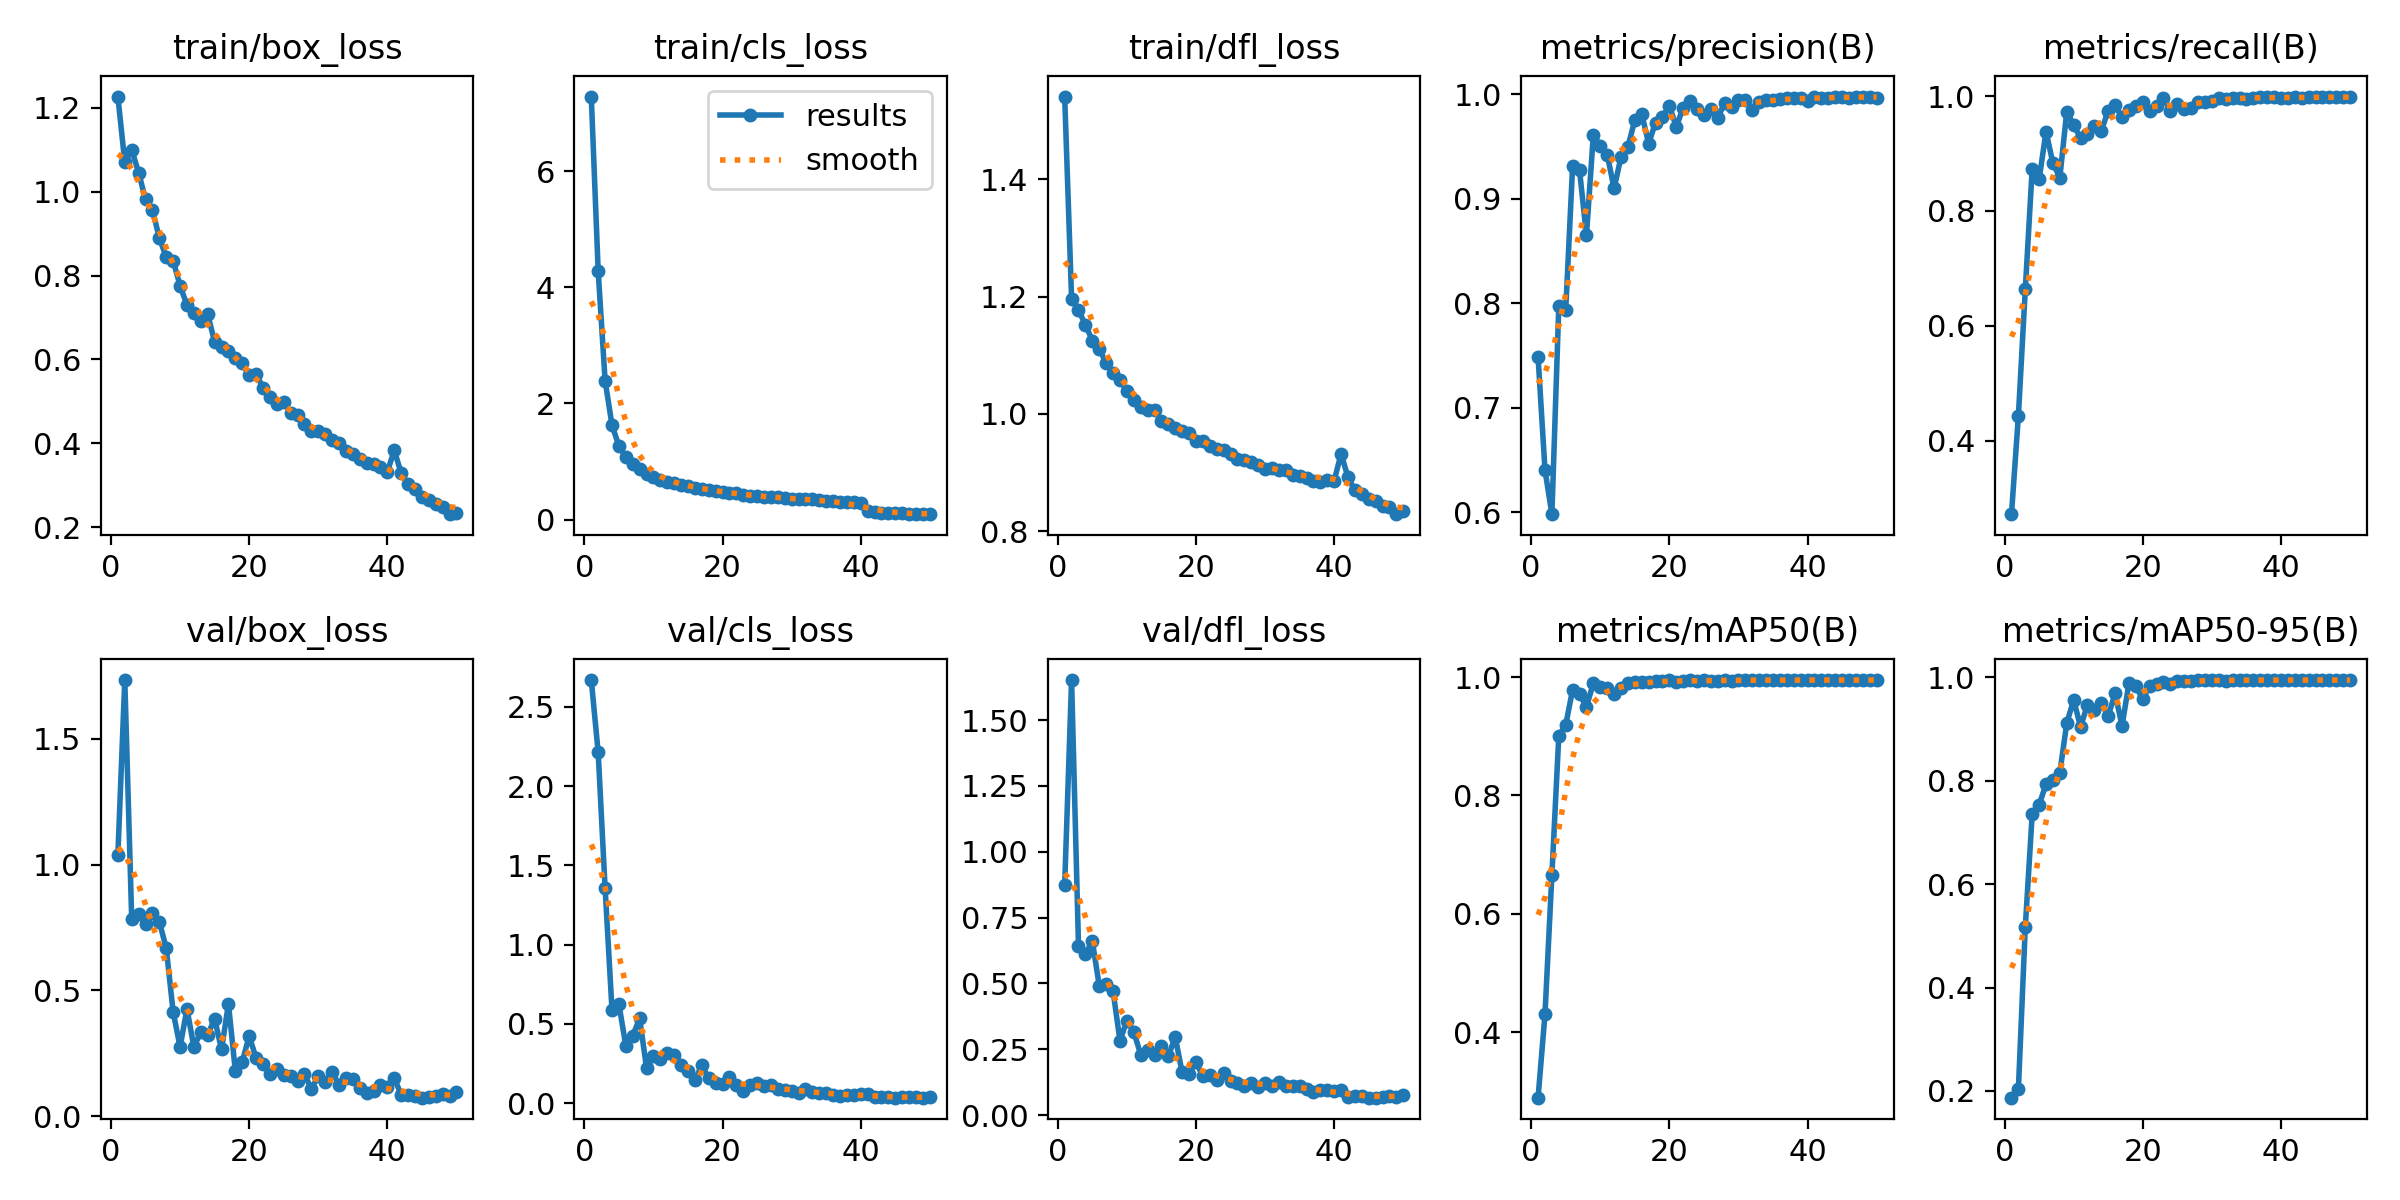

In [20]:
from IPython.display import Image

Image('/kaggle/working/runs/detect/emergsign_yolov10/results.png')


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1952.1±541.8 MB/s, size: 114.1 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 1025 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1025/1025 477.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 65/65 7.8it/s 8.3s0.1s
                   all       1025       1025      0.997      0.999      0.995      0.995
              accident        115        115      0.997          1      0.995      0.995
                  call        125        125       0.99          1      0.995      0.995
                doctor        151        151          1          1      0.995      0.995
                  help        130        130      0.997          1      0.995      0.995
                   hot        134        134          1      0.993      0.995      0.995
                  lose

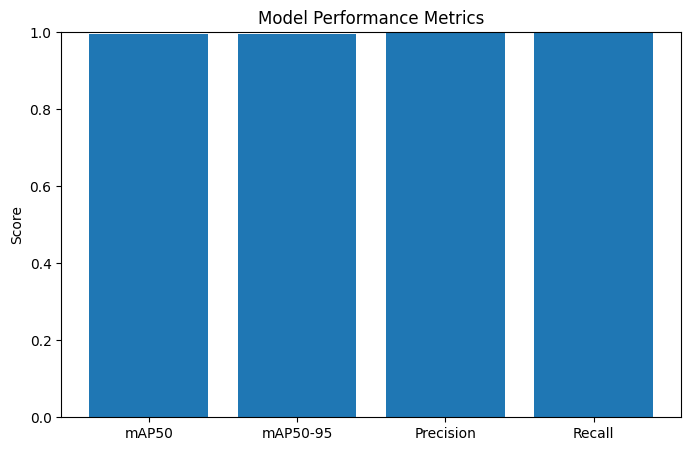

In [21]:
metrics = model.val(data='/kaggle/working/emergency_signs.yaml')

values = [
    metrics.box.map50,
    metrics.box.map,
    metrics.box.mp,
    metrics.box.mr
]

labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylim(0,1)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()
